# Financial Data Science (Projectcourse SS26): Final Assignment

## Task 6: Yield Curves (Nelson-Siegel model)

The Nelson-Siegel model is widely used to model yield curves and is given by

$$
y_t(\tau)=\beta_{1,t}+\beta_{2,t}\frac{1-e^{-\lambda_t\tau}}{\lambda_t\tau}+\beta_{3,t}\left(\frac{1-e^{-\lambda_t\tau}}{\lambda_t\tau}-e^{-\lambda_t\tau}\right),
$$


where $y_t$ is the yield at time t, $\tau$ is the maturity in months, and $\lambda_t$ is an externally specified
parameter. The file yield_curve.xlsx contains yields for several maturities at one point in time.

In [ ]:
# Task 6 - Yield Curves (Nelson-Siegel model)
# Group: 3
# Members: Benita Bullatovci, Lena Bahati, Tom Jilg, Tsvetelin Naydenov,
#          Lisa Singer, Leonardo Sitzia

# Preparation: Importing necessary libraries
import numpy as np  # "Numerical Python", used for numerical calculations
import pandas as pd  # used for loading and handling the data
import matplotlib.pyplot as plt  # used for plotting the yield curves
import os  # "Operating System", used for handling file paths
from IPython.display import display  # render result tables in the notebook

# Set the data path here, then the notebook runs top to bottom
base_directory = os.getcwd()  # Gets the current working directory
# Print the base directory to verify it's correct
print("Base directory: " + base_directory)

# Constructs the full path to the data file
data_path = os.path.join(base_directory, "yield_curve.xlsx")
print("Data path: " + data_path)  # Print the data path to verify it

# Externally specified Nelson-Siegel decay parameter:
# not Python's reserved "lambda" keyword
LAMBDA = 0.06  # global constant initialized with 0.06,
# is given by the task and will be used in Tasks 6.2-6.4

Base directory: /home/tsetsi/Python/financial-data-science-jupyter
Data path: /home/tsetsi/Python/financial-data-science-jupyter/data/yield_curve.xlsx


## 6.1 Import the data and plot the yield curve

Raw_check data preview:
                        0                     1
0    Yield Curve Data on    1989-03-31 00:00:00
1                     NaN                   NaN
2  Yield (in Percentages)  Maturity (in Months)
3                    9.12                     3
4                    9.32                     6
Raw_check data shape: (20, 2)


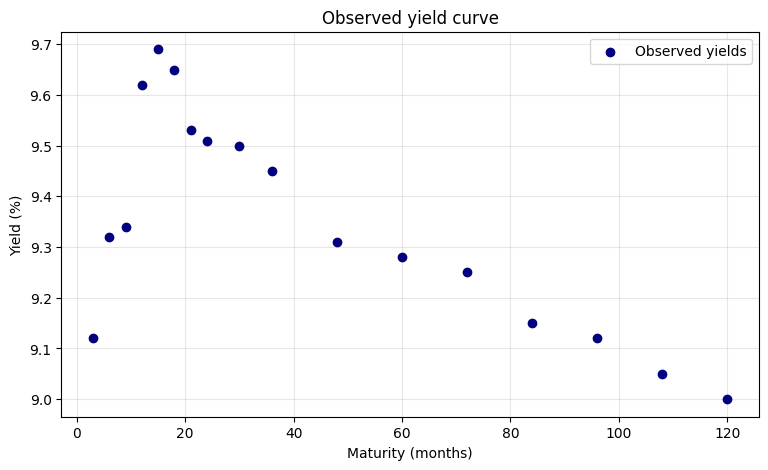

In [13]:
# Initial check of the data: to understand its structure and content,
# possible adaption needed for the later analysis
raw_check = pd.read_excel(data_path, header=None)

# shows the first 5 top rows
# The file has a title in row 1, a blank row 2 and the headers in row 3,
# then the data
print("Raw_check data preview:" + "\n" + str(raw_check.head()))

# shows rows x columns
print("Raw_check data shape: " + str(raw_check.shape))


# Import of the data, based on prior analysis of the raw data structure
# skip the first two rows, reads row 3 as the header
raw = pd.read_excel(data_path, skiprows=2)

# rename the two columns
raw.columns = ["yield", "maturity"]

# Cleaned data: dropna to remove rows with empty cells, reset_index to get
# a clean index after dropping rows.
# no na/is just defensive (in case of an empty trailing row); in this case
# it removes nothing as after row three in the excel file, there are no
# empty cells
data = raw.dropna().reset_index(drop=True)

# Create yield and maturity vectors, array datatype set to float for
# consistency in later calculations
yields = data["yield"].to_numpy(dtype=float)         # in percent
maturities = data["maturity"].to_numpy(dtype=float)  # in months (3 .. 120)


# Optional : Initial view and check of the to be analysed data
# print("Number of observations:", yields.size)
# print("Data:" + "\n" + str(data))
# print("Summary statistics:" + "\n" + str(data.describe()))
# print("Data types:" + "\n" + str(data.dtypes))


# The dataset is clean, maturities are strictly increasing and all yields
# lie in a narrow, economically plausible 9.0%-9.7% range, so no outlier
# treatment is required for a clean visualisation.
# Plot the observed yield curve as a well-formatted scatter plot
fig1, ax1 = plt.subplots(figsize=(9, 5))
ax1.scatter(maturities, yields, color="navy", zorder=3,
            label="Observed yields")
ax1.set_title("Observed yield curve")
ax1.set_xlabel("Maturity (months)")
ax1.set_ylabel("Yield (%)")
ax1.grid(True, alpha=0.3)  # alpha 0.3 = faint gridlines, still readable
ax1.legend()
plt.show()

# Key findings
# The curve is humped. Yields rise from about 9.12% at 3 months to a peak
# near 9.69% around 15 months and then fall back to 9.00% at 120 months.
# The 3-month yield is only about 12 bps above the 120-month yield, so the
# curve is barely inverted at the ends; the main feature is the hump in the
# middle.
# The data are from March 1989, when rates were high (around 9%). A curve
# that peaks in the 1 to 2 year area and then drifts lower is what you would
# expect if the market thinks short rates will come down somewhat later on.
# The hump is exactly what the curvature factor is for.

## 6.2 OLS estimation with $\lambda_t = 0.06$

For a fixed $\lambda$ the regressors only depend on the maturities, so we build the design matrix without a loop and solve the normal equations $\hat\beta=(X'X)^{-1}X'y$.

In [14]:
def ns_design_matrix(maturities, lam):
    """Return the Nelson-Siegel regressor matrix X.

    Columns: Loadings for the three factors of the Nelson-Siegel model
    -------
    0 : 1 (constant)                      -> level loading (for beta1)
    1 : (1 - exp(-lam*tau)) / (lam*tau)   -> slope loading (for beta2)
    2 : column 1 - exp(-lam*tau)          -> curvature loading (for beta3)

    The limit of column 1 (slope loading) as lam*tau -> 0 equals 1; this
    case is handled explicitly to keep the construction numerically safe.
    Construction is fully vectorised - no for-loops.
    """

    # calculation of lambda*tau, vectorized for all maturities at once
    lt = lam * np.asarray(maturities, dtype=float)

    # the np.where guards the 0/0 case: if lt is zero, slope_loading is set
    # to 1.0, otherwise it is calculated as (1 - exp(-lt)) / lt
    slope_loading = np.where(lt == 0.0, 1.0, (1.0 - np.exp(-lt)) / lt)

    # reuse slope_loading, just subtract exp(-lt)
    curvature_loading = slope_loading - np.exp(-lt)

    # Optional: print statements for debugging and understanding the
    # intermediate steps of the design matrix construction, only as comment
    # for cleaner output
    # print("lt:")
    # print(lt)
    # print(slope_loading)
    # print(curvature_loading)

    # the first vector is the level loading - constant at 1, the second
    # vector is the slope loading and the third vector is the curvature
    # loading, all for all maturities at once.
    # column_stack puts the three 1D vectors next to each other AS COLUMNS,
    # giving an n x 3 matrix (number of maturities x amount of loadings).
    # order matters: columns are multiplied by respective betas.
    # ones_like(lt) creates a vector filled with ones in the shape of lt
    return np.column_stack(
        [np.ones_like(lt), slope_loading, curvature_loading]
    )

In [15]:
# Calling the above defined function ns_design_matrix with the 17 real
# maturities and the specified LAMBDA to construct the design matrix X for
# the OLS estimation.
# fixed LAMBDA (0.06) previously defined as global constant
X = ns_design_matrix(maturities, LAMBDA)

# Optional: Print of intermediate results - check the values and dimensions
# of the matrices involved in the OLS estimation to ensure they are
# compatible for matrix multiplication
# X
# print("X: (17 x 3)")  # expectation
# print("X.shape: " + str(X.shape))  # should be (17, 3)
# print("X:" + "\n" + str(X))

# X.T  - X transposed
# print("X.T: (3 x 17)")  # expectation
# print("X.T.shape: " + str(X.T.shape))  # should be (3, 17)
# print("X.T:" + "\n" + str(X.T))

# Product X.T @ X (ensure it is a 3x3 matrix)
# print("X.T @ X: (3 x 3)")  # expectation
# print("X.T @ X:" + "\n" + str(X.T @ X))  # should be (3, 3), check values


# Calculation inverse of X.T @ X, needed for the OLS formula
XtX_inv = np.linalg.inv(X.T @ X)


# Optional: Print of XtX_inv results - check the values and dimensions of
# the inverse involved in the OLS estimation to ensure they are compatible
# for matrix multiplication
# print("XtX_inv: (3 x 3)")  # expectation
print("XtX_inv.shape: " + str(XtX_inv.shape))  # should be (3, 3)
print("XtX_inv:" + "\n" + str(XtX_inv))


# Calculate OLS estimates
# Shape check: (3x3) @ (3x17) @ (17,) = (3x3) @ (3,) = (3,) (the inner 3 and
# 17 cancel -> Result: 1D array (3,) with 3 coefficients, one per loading)
# closed-form solution: beta_ols = (X'X)^-1 X'y
beta_ols = XtX_inv @ X.T @ yields

# Print the estimated beta coefficients
print("lambda =", LAMBDA)
print("beta1 (level)     = %.4f" % beta_ols[0])  # rounded to 4 decimals
print("beta2 (slope)     = %.4f" % beta_ols[1])
print("beta3 (curvature) = %.4f" % beta_ols[2])

# Optional
# short rate = level + slope. positive slope -> short end above long-run
# level
print("short rate beta1+beta2 = %.4f" % (beta_ols[0] + beta_ols[1]))

XtX_inv.shape: (3, 3)
XtX_inv:
[[ 1.01389703 -0.50614609 -3.28516553]
 [-0.50614609  0.95794872  0.26044313]
 [-3.28516553  0.26044313 14.47813888]]
lambda = 0.06
beta1 (level)     = 8.5623
beta2 (slope)     = 0.4785
beta3 (curvature) = 2.5622
short rate beta1+beta2 = 9.0408


## 6.3 Estimation function `nsOLS`

`nsOLS(yields, maturities, lambda)` returns the OLS coefficients with classical, White (heteroskedasticity-robust) and Newey-West standard errors, verifies against 6.2, and displays a fitted table.

In [16]:
# nw_lag=None sets the default value for nw_lag to None. If not passed, the
# function calculates the lag based on the number of observations by using a
# standard formula; pass a value to override it.
def nsOLS(yields, maturities, lam, nw_lag=None):
    """Return the Nelson-Siegel model by OLS:

    The function estimates the Nelson-Siegel model (as in 6.2) via
    ns_design_matrix, sorts the observations by maturity so that neighbouring
    maturities are adjacent (required for the Newey-West step), and solves the
    normal equations beta_hat = (X'X)^-1 X'y. The residuals e = y - X @ beta
    are the basis for all standard errors and for the R-squared.

    It returns a dictionary containing the OLS coefficients together with
    three sets of standard errors, the R-squared and the Newey-West lag used.
    The SE make progressively weaker assumptions about the error term. They
    differ only in the "core" C of the calculation (X'X)^-1 @ C @ (X'X)^-1.

    Parameters
    ----------
    yields     : array of observed yields, one value per maturity (y vector)
    maturities : array of maturities in months (the tau vector)
    lam        : float, the fixed Nelson-Siegel decay parameter, global
                 constant LAMBDA initialized with 0.06
    nw_lag     : int, optional, amount of considered neighbours for the
                 Newey-West estimator. If None (default), it is set by the
                 standard formula based on the amount of observations
                    nw_lag = int(np.floor(
                        4.0 * (n_observations / 100.0) ** (2.0 / 9.0)))
                 nw_lag = 0 makes the Newey-West standard errors collapse to
                 the White standard errors.

    Returns
    -------
    dict with keys
        coef       : (3,) OLS coefficients [beta1 (level), beta2 (slope),
                     beta3 (curvature)]
        se_ols     : (3,) classical OLS standard errors
        se_white   : (3,) White (HC0) heteroskedasticity-robust SE
        se_nw      : (3,) Newey-West (HAC) standard errors
        residuals  : (17,) OLS residuals
        r2         : float, R-squared
        nw_lag     : int, actually used lag length (considered neighbours)

    Standard errors/SE:
    ---------------
    Standard errors are the square root of the diagonal elements (the
    variances of the coefficient estimates) of the covariance matrix.

    Classical OLS:
        Classical OLS SE have the strictest assumptions: They assume the
        error terms (residuals) are homoskedastic (constant variance) and
        uncorrelated. If these assumptions are violated, the OLS standard
        errors may be biased and lead to incorrect inference about the
        statistical significance of the coefficients.
        Var(beta) = s^2 (X'X)^-1 with s^2 = e'e / (n - k)

    White (HC0):
        The Classical OLS assumptions are often unrealistic in practice,
        especially with time series data or cross-sectional data with
        heteroskedasticity, which is why White standard errors relax the
        assumption of homoskedasticity: each observation may have its own
        error variance, but errors are still treated as uncorrelated.
        The core is C = sum_i e_i^2 x_i x_i', implemented as x_res.T @ x_res,
        where each row of X is scaled by its own residual.

    Newey-West (HAC):
        Newey-West (HAC) standard errors additionally allow the errors to be
        correlated across neighbouring maturities. Starts from the White core
        (the lag-0 term) and adds weighted autocovariance terms for lags
        1..L. For each lag it forms the cross-product g of every observation
        with its lag-step neighbour and adds w * (g + g.T), where
        w = 1 - lag / (L + 1) is the Bartlett weight, so close neighbours
        count more and distant ones taper to zero. This keeps the estimate
        positive semi-definite and makes the standard errors robust to both
        heteroskedasticity and autocorrelation.

        nw_lag=None sets the default value for nw_lag to None, which means
        that if you call nsOLS without providing a value for nw_lag, it will
        automatically be set to None. This allows the function to handle the
        case where the user does not specify a lag length for the Newey-West
        standard error calculation, and it can then choose an appropriate lag
        length based on the number of observations in the dataset. If you do
        provide a value for nw_lag when calling nsOLS, that value will be used
        instead of the default None.
    """

    # Convert input series to NumPy float arrays so the OLS calculations
    # work consistently
    y = np.asarray(yields, dtype=float)
    tau = np.asarray(maturities, dtype=float)

    # Sort by maturity for Newey-West neighbor-based autocorrelation.
    # Newey-West treats adjacent maturities as neighbours, so we must order
    # the data by tau.
    order = np.argsort(tau)  # argsort returns the indices that sort tau
    # applying the same order to y and tau keeps each yield paired with its
    # maturity
    y = y[order]
    tau = tau[order]

    # new x matrix variable with sorted taus and ys based on tau-order
    # (increasing maturity)
    x_mat = ns_design_matrix(tau, lam)
    # x_mat is (17x3) matrix -> n_observations is the number of rows
    # (n = 17 data points), k_parameters is the number of columns
    # (k = 3 parameters)
    n_observations, k_parameters = x_mat.shape

    # Optional: Print of intermediate results - check the values and
    # dimensions of the matrices involved in the SE calculations to ensure
    # they are compatible for matrix multiplication
    print("x_mat.shape:", str(x_mat.shape))  # should be (17, 3)
    print("n_observations:", str(n_observations))
    print("k_parameters:", str(k_parameters))

    # Calculation inverse of X.T @ X, needed for the SE calculations
    xtx_inv = np.linalg.inv(x_mat.T @ x_mat)

    # beta coefficients calculated using the OLS formula: beta = (X'X)^-1 X'y
    coef = xtx_inv @ x_mat.T @ y

    # residuals are the basis for all SE and for R^2.
    # the result is a 1D vector (17,) with no second dimension (17 is neither
    # row nor column)
    residuals = y - x_mat @ coef

    # print("residuals shape:", str(residuals.shape))  # should be (17,)
    # print("residuals:", str(residuals))

    # Classical OLS SE
    sigma2 = (residuals @ residuals) / (n_observations - k_parameters)
    se_ols = np.sqrt(np.diag(sigma2 * xtx_inv))

    # White (HC0) SE
    # residuals[:, None] converts 1D array residuals with (17,) to a 2D
    # column array of shape (17, 1). (17x3) * (17x1) -> (17x3) element-wise
    # multiplication, each column of x_mat is multiplied by the corresponding
    # residual for that row
    x_res = x_mat * residuals[:, None]
    # (3x17) @ (17x3) -> (3x3) matrix, this is the core of the White SE
    # formula, it captures the heteroskedasticity by weighting the X matrix
    # with the squared residuals
    core = x_res.T @ x_res
    # Covariance matrix for White SE (variances of the coefficient estimates
    # on the diagonal and zeros elsewhere as white SE assume no correlation
    # between the error terms)
    cov_white = xtx_inv @ core @ xtx_inv
    se_white = np.sqrt(np.diag(cov_white))  # result for White SE

    # Newey-West (HAC) SE

    # nw_lag = amount of considered neighbours
    # nw_lag calculation in case it is not provided as an argument when
    # calling the function
    if nw_lag is None:
        # the larger n_observations, the larger nw_lag (more adjacent
        # residual correlations are included in the covariance core)
        nw_lag = int(np.floor(
            4.0 * (n_observations / 100.0) ** (2.0 / 9.0)))

        # prints the calculated nw_lag for debugging
        # print("nw_lag:", nw_lag)

    # lag = current neighbour distance we iterate over.
    # the for-loop iterates lag = 1, 2, ..., nw_lag (upper limit of range /
    # to be considered neighbours) (each lag = one neighbour distance).
    # starts at 1, not 0: lag 0 is already in the White core (no neighbour
    # correlation, white SE doesn't consider lags, i.e. lag=0), lags > 0 add
    # neighbour correlation.
    for lag in range(1, nw_lag + 1):
        # Bartlett weight: larger lags get smaller weight, so farther
        # neighbours contribute less to the covariance core
        w = 1.0 - lag / (nw_lag + 1.0)
        # cross-product pairing each point with its neighbour: `lag` steps
        # back (shift drops `lag` rows at each end)
        g = x_res[lag:].T @ x_res[:-lag]
        # example for further understanding:
        # x_res[lag:] = rows from position lag on -> at lag 1: P2..P17
        #   (drops first row P1)
        # x_res[:-lag] = rows up to lag before the end -> at lag 1: P1..P16
        #   (drops last row P17)
        # for Newey-West we add the information about correlation between
        # errors based on amount of lags and their responding values and
        # weighting, with g being a 3x3 matrix
        core += w * (g + g.T)

    cov_nw = xtx_inv @ core @ xtx_inv  # Covariance matrix for Newey-West SE
    se_nw = np.sqrt(np.diag(cov_nw))  # result for Newey-West SE

    # R squared: 1 - (SSR / SST)
    #          = 1 - (residuals @ residuals) / np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - (residuals @ residuals) / np.sum((y - y.mean()) ** 2)

    # return dictionary with named keys for easy, readable access
    return {"coef": coef, "se_ols": se_ols, "se_white": se_white,
            "se_nw": se_nw, "residuals": residuals, "r2": r2,
            "nw_lag": nw_lag}

In [17]:
# nw_lag not passed, so the function uses its default (None) and computes
# the lag from the number of observations
result_nsOLS = nsOLS(yields, maturities, LAMBDA)

# Optional: Print of final results - check the values and dimensions of the
# results to ensure they are consistent with expectations and correct
print("Result of nsOLS ")
print(result_nsOLS)


# Verify nsOLS reproduces 6.2:
# res["coef"] - beta_ols subtracts ELEMENTWISE (both are shape (3,)), giving
# 3 differences (between the coefficients from nsOLS and the estimated OLS
# coefficients from 6.2).
# np.abs makes them all positive (so + and - errors don't cancel),
# np.max takes the largest single difference.
# coef is pulled from the dictionary via the key "coef".
# if that max is ~0, every coefficient matches -> reproduces 6.2.
print("max diff to 6.2:", np.max(np.abs(result_nsOLS["coef"] - beta_ols)))


# Optional: Print of additional results
# R-squared is pulled from the dictionary via the key "r2"
print("R-squared:", round(result_nsOLS["r2"], 4))
# NW lag is pulled from the dictionary via the key "nw_lag"
print("NW lag:", result_nsOLS["nw_lag"])

# Build dataframe for results table
result_nsOLS_table = pd.DataFrame(
    {"Coefficient": result_nsOLS["coef"],
     "SE (OLS)": result_nsOLS["se_ols"],
     "SE (White)": result_nsOLS["se_white"],
     "SE (Newey-West)": result_nsOLS["se_nw"]},
    index=["beta1 (level)", "beta2 (slope)", "beta3 (curvature)"],
).round(4)


# Display results of nsOLS in a fitting table
display("Results nsOLS:")
display(result_nsOLS_table)

# Optional - comparison of print and display
# print("Results nsOLS: " + "\n" + str(result_nsOLS_table))

# Key findings
# The coefficients match 6.2 exactly, which checks the function.
# The White errors come out a bit below the classical ones.
# Across all versions beta_3 (curvature) has by far the largest standard
# error.

x_mat.shape: (17, 3)
n_observations: 17
k_parameters: 3
Result of nsOLS 
{'coef': array([8.56232424, 0.47846376, 2.56220278]), 'se_ols': array([0.08296422, 0.0806427 , 0.3135092 ]), 'se_white': array([0.0505034 , 0.06614637, 0.24953279]), 'se_nw': array([0.06625575, 0.07775118, 0.32387108]), 'residuals': array([-0.08490567, -0.00825123, -0.07869287,  0.13731258,  0.16447437,
        0.09846449, -0.03425084, -0.05655077, -0.04882149, -0.06220887,
       -0.10501623, -0.03386649,  0.02725599,  0.00486162,  0.0395195 ,
        0.02308676,  0.01758916]), 'r2': np.float64(0.8723562012800674), 'nw_lag': 2}
max diff to 6.2: 0.0
R-squared: 0.8724
NW lag: 2


'Results nsOLS:'

,Coefficient,SE (OLS),SE (White),SE (Newey-West)
beta1 (level),8.5623,0.0830,0.0505,0.0663
beta2 (slope),0.4785,0.0806,0.0661,0.0778
beta3 (curvature),2.5622,0.3135,0.2495,0.3239


## 6.4 Fitted curve and interpretation

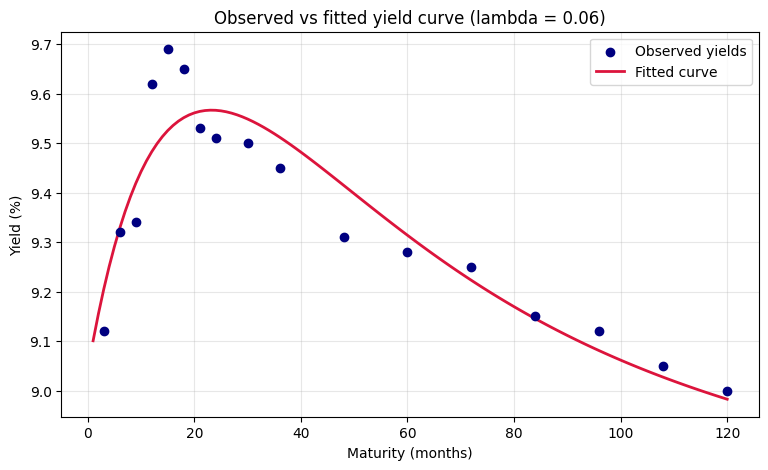

R-squared: 0.8724
residual std: 7.48 bps


In [18]:
# Create an array of evenly spaced numbers
# np.arange(start, stop, step): start included, stop excluded, default step
# 1 -> 120 values (months 1, 2, ..., 120)
grid = np.arange(1, 121, dtype=float)

# Compute the curve from the 6.2 estimates on a 1 to 120 month grid, not
# like previously done with 17 specific data points.
# ns_design_matrix is now called with grid as a parameter for maturities,
# (120 x 3) @ (3,) -> (120,): one fitted yield per grid point = whole curve
fitted = ns_design_matrix(grid, LAMBDA) @ beta_ols

# Add the fitted curve to the scatter plot
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.scatter(maturities, yields, color="navy", zorder=3,
            label="Observed yields")
ax2.plot(grid, fitted, color="crimson", linewidth=2,
         label="Fitted curve")
ax2.set_title("Observed vs fitted yield curve (lambda = 0.06)")
ax2.set_xlabel("Maturity (months)")
ax2.set_ylabel("Yield (%)")
ax2.grid(True, alpha=0.3)  # 0.3 suitable visibility of the gridlines
ax2.legend()
plt.show()

# Additional information: R-squared and residual standard deviation
print("R-squared: %.4f" % result_nsOLS["r2"])
print("residual std: %.2f bps" % (np.std(result_nsOLS["residuals"]) * 100.0))

Interpretation:

Comment on the model fit:
The fit is good: $R^2\approx0.87$ and a residual standard deviation of about 7.5 bps. The fitted curve tracks the observed points closely across almost the whole maturity range; the most visible gap is around the hump. It is not perfect, and the reason is visible in the plot. Yields jump from 9.34% at 9 months to 9.62% at 12 and 9.69% at 15 months, roughly +35 bps over two quarters, and a smooth three-factor curve cannot bend that sharply, so the largest residuals sit right at the peak.

Economic interpretation of the shape of the curve:

The estimates give a high short rate ($\beta_1$ + $\beta_2$ ≈ 9.04%), a slightly lower long-run anchor ($\beta_1$ ≈ 8.56%), and a strong positive curvature ($\beta_3$ ≈ 2.56) that bows the belly of the curve upward into a hump around the 1–2 year area. This hump-with-slightly-inverted-tail pattern typically reflects a market pricing in near-term rates staying high (or rising a touch) but easing over the longer run, from an already high March-1989 level.

## 6.5 Uncertainty in $\lambda_t$

Curves shape:(5000, 120)


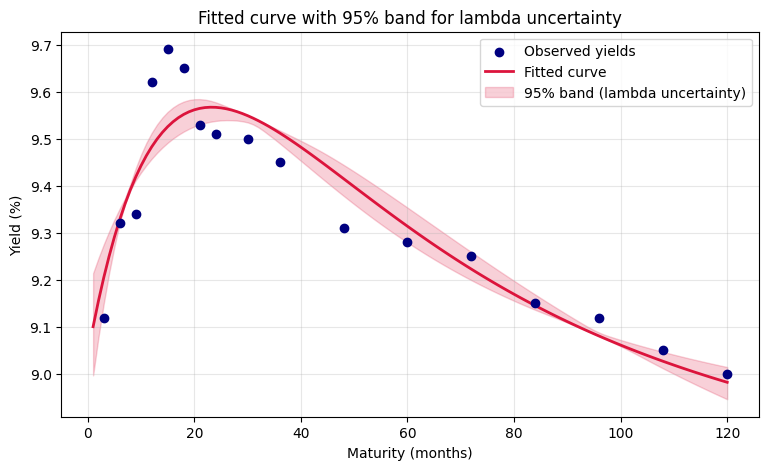

negative lambda draws: 0.0
band width: max 21.7, mean 4.8 bps


In [19]:
# So far (6.2-6.4) we fitted one curve with a lambda that was GIVEN from
# outside (0.06), which is itself an uncertain assumption.
# Now (6.5) we assume lambda is uncertain: We draw 5000 lambdas from
# N(0.06, 0.01^2), refit the curve for each, and build 95% confidence bands
# (2.5%/97.5% percentile per maturity) to see how much the yield curve moves.

# For each draw we re-estimate beta by OLS (each lambda has its own
# best-fitting beta). Beta moves opposite to the loadings, so most of the
# lambda-change cancels (self-correction).
# If instead we kept beta fixed at the 6.2 values and only changed the
# loadings, the 95% confidence band would come out several times wider;
# we use the re-estimated version and state it as our assumption.

# Fixed seed for the random number generator -> reproducible (same sequence
# of random numbers on every run).
# Creates a new NumPy random number generator with a fixed seed (100),
# without a seed np.random.default_rng() would give different draws each run
rng = np.random.default_rng(100)
# Generates 5000 random draws of lambda from a normal distribution with mean
# 0.06 and standard deviation 0.01
draws = rng.normal(0.06, 0.01, 5000)

# Optional: Sanity check on the draws
# print("Lambda draws:")
# print(draws)
# min and max should be above 0
# print(draws.min(), draws.max(), draws.mean(), draws.std())


# one fitted curve per draw.
# Creates an empty NumPy array with shape of (rows, columns). The loop later
# fills every row. This array will be filled with the fitted yield values
# for each combination of lambda draw and grid point in the subsequent loop.
curves = np.empty((draws.size, grid.size))

# Curves shape: (5000, 120). (5000) = number of lambda draws we generated,
# (120) = number of grid points (maturities from 1 to 120 months)
print("Curves shape:" + str(curves.shape))


# print(curves.dtype)  # dtype('float64')
# print(curves)  # check to see if all cells are empty


# Loop over all 5000 lambdas using maturities (17 real data points) in each
# iteration to estimate yield curves from 1 to 120 months.
# Curves is 5000 x 120: 5000 yield curves. each row is one curve, computed
# with one lambda draw and its estimated coefficients beta_i.

# each iteration 0-4999 returns the value of current element lam_i at the
# respective index from draws
for i, lam_i in enumerate(draws):
    # maturities (17 real maturities) and draws (5000 lambdas) are separate,
    # the loop runs over all 5000 lambdas and in every iteration the full 17
    # maturities are used to estimate beta
    xm = ns_design_matrix(maturities, lam_i)  # design matrix for this lambda

    # in 6.2 it was explicitly required to calculate the inverse, but here we
    # can use solve for better performance and stability, especially since
    # this loops 5000 times.
    # use design matrix xm to estimate OLS coefficients beta_i per iteration
    beta_i = np.linalg.solve(xm.T @ xm, xm.T @ yields)

    # evaluate the yield curve on all grid points (1-120) with this lambda
    # draw and its estimated beta_i. result = a vector of 120 values (the
    # fitted yields at the 120 grid points), overwriting the empty rows as
    # row i of curves
    curves[i] = ns_design_matrix(grid, lam_i) @ beta_i


# percentile of the curves across the 5000 simulations for each grid point.
# np.percentile(input array, percentile, axis=0 says that the calculation is
# done separately for all columns)
lower_band = np.percentile(curves, 2.5, axis=0)
upper_band = np.percentile(curves, 97.5, axis=0)  # the 97.5% percentile
# 95% confidence band
width = (upper_band - lower_band) * 100.0

# Add the upper and lower bands to the existing 6.4 figure
fig3, ax3 = plt.subplots(figsize=(9, 5))
ax3.scatter(maturities, yields, color="navy", zorder=3,
            label="Observed yields")
ax3.plot(grid, fitted, color="crimson", linewidth=2,
         label="Fitted curve")
# fill_between shades the area between lower and upper band
ax3.fill_between(grid, lower_band, upper_band, color="crimson", alpha=0.2,
                 label="95% band (lambda uncertainty)")
ax3.set_title("Fitted curve with 95% band for lambda uncertainty")
ax3.set_xlabel("Maturity (months)")
ax3.set_ylabel("Yield (%)")
ax3.grid(True, alpha=0.3)
ax3.legend()
plt.show()

# Optional
# np.mean assesses share of lambdas that are negative or 0 (economically
# implausible). expected 0.0.
print("negative lambda draws:", np.mean(draws <= 0.0))

# band width that helps us answer high/low uncertainty in our fitted yield
# curve due to the uncertainty in lambda
print("band width: max %.1f, mean %.1f bps"
      % (width.max(), width.mean()))

Interpretation:

We draw 5000 values of $\lambda$ from N(0.06, 0.01²), refit the curve for each draw, and take the 2.5%/97.5% percentile at every maturity to form a 95% band. The uncertainty in $\lambda$ translates into low uncertainty about the curve. 

The uncertainty in $\lambda$ translates into low uncertainty about the curve. With sd 0.01 almost all draws stay between about 0.03 and 0.09, none turn negative, and the band is about 5 bps wide on average (at most around 22 bps at the very short end). The band is widest where the slope and curvature loadings react most to $\lambda$, i.e. at short maturities, and is close to flat for medium and long ones. Part of why it is so tight is that re-estimating $\beta$ lets the factors soak up most of the change in $\lambda$. Against a yield level near 9%, a few bps either way is small, so the curve is robust to this much uncertainty in $\lambda$.

The tight band depends on re-estimating β for each draw: β moves opposite to the loadings, so most of the λ-change cancels (self-correction). If β were instead held fixed at the 6.2 values, the band would be roughly five times wider (~23 vs ~5 bps) — "moderate" rather than "low". We use the re-estimated version (the natural reading) and state it as our assumption as stated above.